# NER Prediction + SHAP & LIME Explanations (Fine-tuned DistilBERT)

Loads the DistilBERT model you fine-tuned earlier and uses it to:
1. Predict named entities in a single tweet typed in
2. Explain each predicted entity with SHAP and LIME - two different
   explanation methods - showing which input words pushed the model
   toward that prediction

**Requires:** the saved model folder from the training notebook's final
step (`trainer.save_model(SAVE_PATH)` / `tokenizer.save_pretrained(SAVE_PATH)`).
No internet access needed here - everything loads from local disk, since
this is your own fine-tuned model, not a Hub download.

## 0. Install dependencies

In [1]:
# !pip install torch transformers shap matplotlib lime -q

## 1. Load your fine-tuned model

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_PATH = "./ner_distilbert_finetuned"  # update if you saved it elsewhere

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH)
model.eval()

id2label = model.config.id2label
label2id = model.config.label2id
print("Labels:", list(id2label.values()))

/Users/aniketchoudhary/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 102/102 [00:00<00:00, 6797.14it/s]

Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


## 2. Prediction function

Splits the tweet on whitespace into words (matching how the model was
trained - word-level BIO tags aligned to subwords via `is_split_into_words`),
runs it through the model, and takes the **first subword's** prediction
as each word's label (the same "first" aggregation convention used
elsewhere in this project).

In [3]:
def predict_entities(text):
    """Returns a list of (word, label, confidence) for every word in text."""
    words = text.split()
    if not words:
        return []

    enc = tokenizer(words, is_split_into_words=True, truncation=True,
                     max_length=64, return_tensors="pt")
    with torch.no_grad():
        logits = model(**enc).logits[0]
    probs = torch.softmax(logits, dim=-1)
    word_ids = enc.word_ids()

    results = []
    seen = set()
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid not in seen:
            seen.add(wid)
            label_id = probs[pos].argmax().item()
            results.append((words[wid], id2label[label_id], probs[pos, label_id].item()))
    return results

## 3. Reconstruct predictions into entity strings

Per-word predictions are useful for inspection, but for a quick summary
of "what entities did the model find," it's more readable to see them
reconstructed back into `LABEL/surface text;` form - the same format as
the ground truth annotations. This groups consecutive `B-X I-X I-X...`
predictions into one entity, the same logic used in the test-set
evaluation notebook.

In [4]:
def bio_to_entities(predictions):
    """predictions: list of (word, label, confidence) from predict_entities().
    Returns a list of (label, surface_text) tuples, reconstructed by
    grouping consecutive B-X I-X I-X... predictions into one entity.
    A fresh B- (even of the same label as the entity right before it)
    always starts a new entity, so adjacent same-type entities aren't
    merged."""
    entities = []
    current_label = None
    current_words = []

    def flush():
        if current_label is not None and current_words:
            entities.append((current_label, " ".join(current_words)))

    for word, label, conf in predictions:
        if label == "O":
            flush()
            current_label, current_words = None, []
        elif label.startswith("B-"):
            flush()
            current_label = label[2:]
            current_words = [word]
        elif label.startswith("I-"):
            ent_label = label[2:]
            if current_label == ent_label:
                current_words.append(word)
            else:
                # I- without a matching preceding B- - treat as a new
                # entity rather than dropping it
                flush()
                current_label = ent_label
                current_words = [word]
    flush()
    return entities


def entities_to_string(entities):
    """[('PER','Christian Bale'), ('MISC','Dark Knight')]
    -> 'PER/Christian Bale;MISC/Dark Knight;'"""
    return "".join(f"{label}/{text};" for label, text in entities)

## 4. Enter a tweet and see predictions

Edit `TWEET` below and re-run this cell for each new tweet you want to
check. Shows per-word predictions first, then the reconstructed
entity-string summary.

In [ ]:
TWEET = "Christian Bale thinks The Dark Knight Rises Will be his Last Batman Movie"

predictions = predict_entities(TWEET)
print(f"Tweet: {TWEET}\n")
for word, label, conf in predictions:
    marker = f"  <-- {label} ({conf:.3f})" if label != "O" else ""
    print(f"  {word:15s}{marker}")

entities = bio_to_entities(predictions)
entity_string = entities_to_string(entities)
print(f"\nReconstructed entities: {entity_string if entity_string else '(none predicted)'}")

Tweet: Christian Bale thinks The Dark Knight Rises Will be his Last Batman Movie

  Christian        <-- B-PER (0.995)
  Bale             <-- I-PER (0.990)
  thinks         
  The            
  Dark           
  Knight           <-- I-MISC (0.542)
  Rises          
  Will           
  be             
  his            
  Last           
  Batman         
  Movie          

Reconstructed entities: PER/Christian Bale;MISC/Knight;


## 5. SHAP setup

Same approach used for the pretrained-model analysis earlier in this
project: SHAP expects a single scalar (or fixed-size) output per input,
but NER produces a variable-length sequence of per-word label
distributions. The fix is to fix *what* we're explaining: for one
specific word the model labeled as an entity, "how much did each word
in the tweet push the model toward that label, at that word's
position." That turns it into a scalar SHAP can attribute against.

In [6]:
import numpy as np
import shap


def make_word_label_predict_fn(target_word_index, target_label_id):
    """Returns predict_fn(list_of_texts) -> np.array of shape (n,):
    P(target_label) at the word position matching target_word_index in
    each (possibly masked/perturbed) version of the text."""

    def predict(texts):
        scores = []
        for text in texts:
            words = text.split()
            if target_word_index >= len(words) or len(words) == 0:
                scores.append(0.0)
                continue
            enc = tokenizer(words, is_split_into_words=True, truncation=True,
                             max_length=64, return_tensors="pt")
            with torch.no_grad():
                logits = model(**enc).logits[0]
            probs = torch.softmax(logits, dim=-1)
            word_ids = enc.word_ids()
            first_subword_pos = next(
                (pos for pos, wid in enumerate(word_ids) if wid == target_word_index),
                None,
            )
            if first_subword_pos is None:
                scores.append(0.0)
                continue
            scores.append(probs[first_subword_pos, target_label_id].item())
        return np.array(scores)

    return predict

## 6. Which categories did the model predict for this tweet?

Before explaining anything, look at the **set of distinct entity
categories** the model predicted anywhere in the tweet - e.g. a tweet
might get `{PER}`, or `{PER, LOC}`, or `{LOC, MISC}`, or nothing at all.
This is the set we'll loop over next: one explanation pass per
category, covering every entity occurrence of that category in the
tweet (so if a tweet has two different PER entities, PER gets two
separate explanations - one per occurrence - grouped together under
the PER heading).

In [7]:
def get_predicted_categories(text):
    """Returns the sorted set of distinct entity categories (bare type,
    no B-/I- prefix) predicted anywhere in the tweet."""
    preds = predict_entities(text)
    categories = set()
    for w, label, c in preds:
        if label != "O":
            categories.add(label.split("-", 1)[1] if "-" in label else label)
    return sorted(categories)


predicted_categories = get_predicted_categories(TWEET)
print(f"Tweet: {TWEET}")
print(f"Predicted categories: {predicted_categories if predicted_categories else '(none - no entities predicted)'}")

Tweet: WikiLeaks Set To Reveal US UFO War In Southern Ocean
Predicted categories: ['LOC', 'ORG']


## 7. Explain each predicted category

For every category found above, this explains **every word's
contribution** to each entity occurrence of that category, grouped
under that category's heading. If a category appears twice in the
tweet (two separate PER names, for example), it gets two separate
explanations, one per occurrence - each is its own SHAP run, since
SHAP explains one specific prediction at a time, not "the category" as
an abstract whole.

For each explained occurrence:

- A **bar plot**: each word's contribution to that specific prediction,
  ranked by size. Red = pushed the model *toward* the predicted label;
  blue = pushed *away* from it.
- A **waterfall plot**: the same information as a running total, from
  the model's baseline probability for that label up to the final
  predicted probability `f(x)`.

You can still pass `categories=[...]` to restrict this to specific
types only (e.g. skip MISC even if it was predicted) - default `None`
covers every predicted category.

In [8]:
import matplotlib.pyplot as plt


def explain_by_category(text, categories=None, show_plots=True):
    """categories: e.g. ['PER'] or ['PER', 'LOC'] to only explain those
    entity types; None (default) explains every predicted category.
    Groups output by category; each entity occurrence within a category
    gets its own SHAP explanation."""
    if categories is not None:
        categories = {c.upper() for c in categories}

    preds = predict_entities(text)

    # group word positions by their bare entity type, preserving order
    positions_by_category = {}
    for i, (w, label, c) in enumerate(preds):
        if label == "O":
            continue
        bare_type = label.split("-", 1)[1] if "-" in label else label
        if categories is not None and bare_type not in categories:
            continue
        positions_by_category.setdefault(bare_type, []).append(i)

    if not positions_by_category:
        if categories is None:
            print("No entities predicted in this tweet - nothing to explain.")
        else:
            print(f"No predicted entities matched categories {sorted(categories)} in this tweet.")
        return

    masker = shap.maskers.Text(tokenizer=r"\W+")

    for category in sorted(positions_by_category):
        word_indices = positions_by_category[category]
        print(f"\n{'=' * 60}")
        print(f"CATEGORY: {category}  ({len(word_indices)} occurrence{'s' if len(word_indices) != 1 else ''})")
        print(f"{'=' * 60}")

        for word_idx in word_indices:
            word, label, conf = preds[word_idx]
            target_label_id = label2id[label]

            predict_fn = make_word_label_predict_fn(word_idx, target_label_id)
            explainer = shap.Explainer(predict_fn, masker)
            shap_values = explainer([text])

            print(f"\nWord: '{word}'  ->  {label}  (confidence={conf:.3f})")

            if show_plots:
                shap.plots.bar(shap_values[0], show=False)
                plt.title(f"[{category}] '{word}' -> {label}  (word-level contributions)")
                plt.show()

                shap.plots.waterfall(shap_values[0], show=False)
                plt.title(f"[{category}] '{word}' -> {label}  (cumulative contribution)")
                plt.show()
            else:
                print("Contribution of each word to this prediction:")
                for tok, val in zip(shap_values.data[0], shap_values.values[0]):
                    bar = "+" * min(int(abs(val) * 200), 40) if val > 0 else "-" * min(int(abs(val) * 200), 40)
                    print(f"  {tok.strip():15s} {val:+.4f}  {bar}")

Examples:
- `explain_by_category(TWEET)` - explain every predicted category (default)
- `explain_by_category(TWEET, categories=["PER"])` - only PER
- `explain_by_category(TWEET, categories=["PER", "LOC"])` - PER and LOC only


CATEGORY: LOC  (2 occurrences)

Word: 'Southern'  ->  B-LOC  (confidence=0.914)


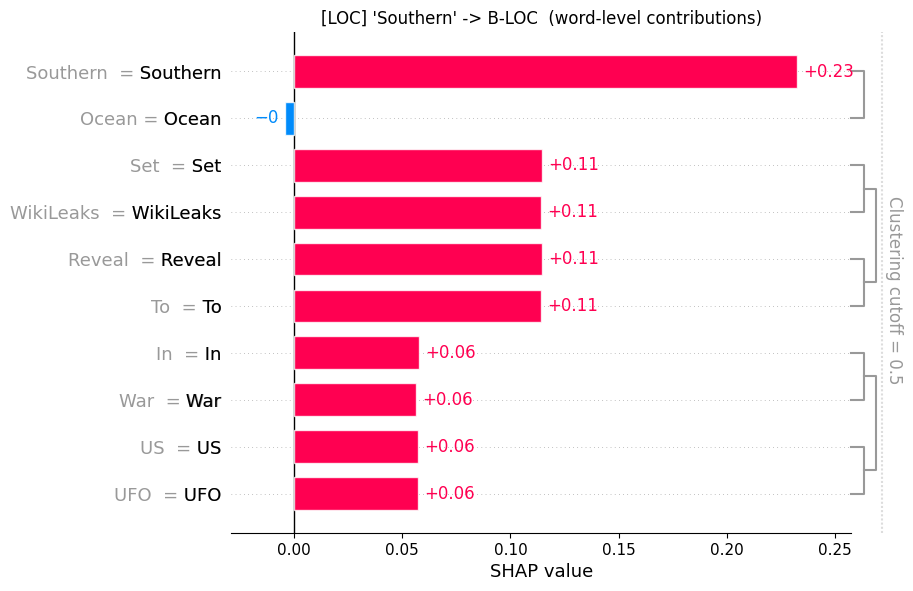

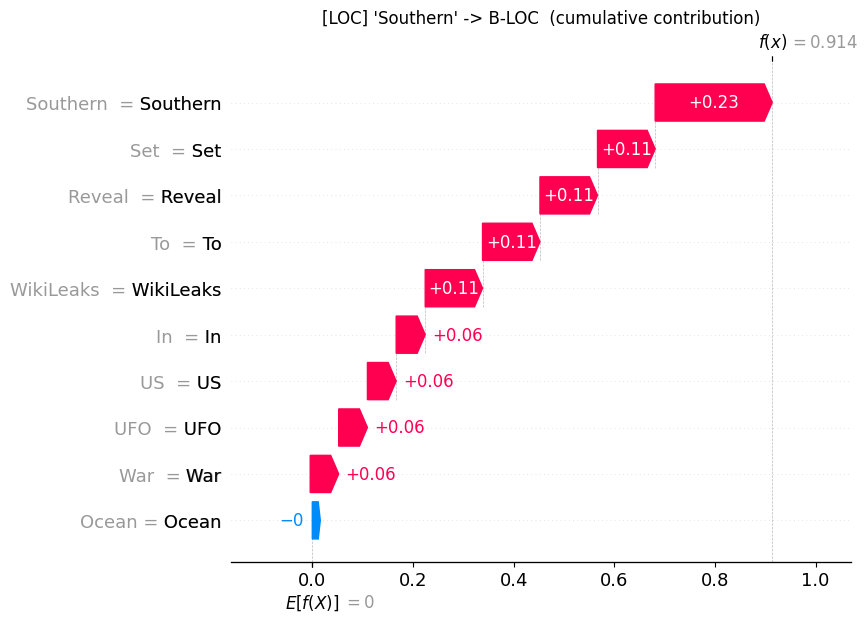


Word: 'Ocean'  ->  I-LOC  (confidence=0.681)


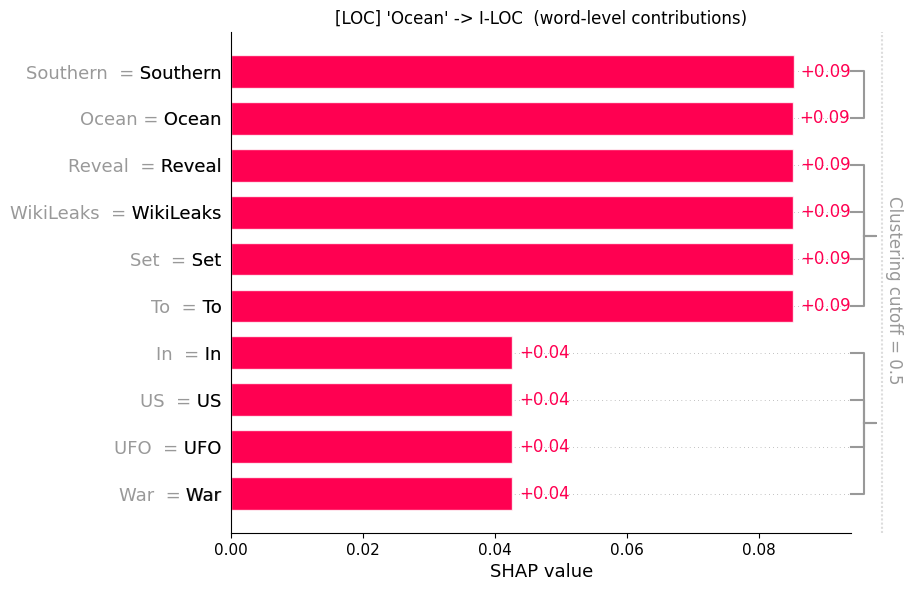

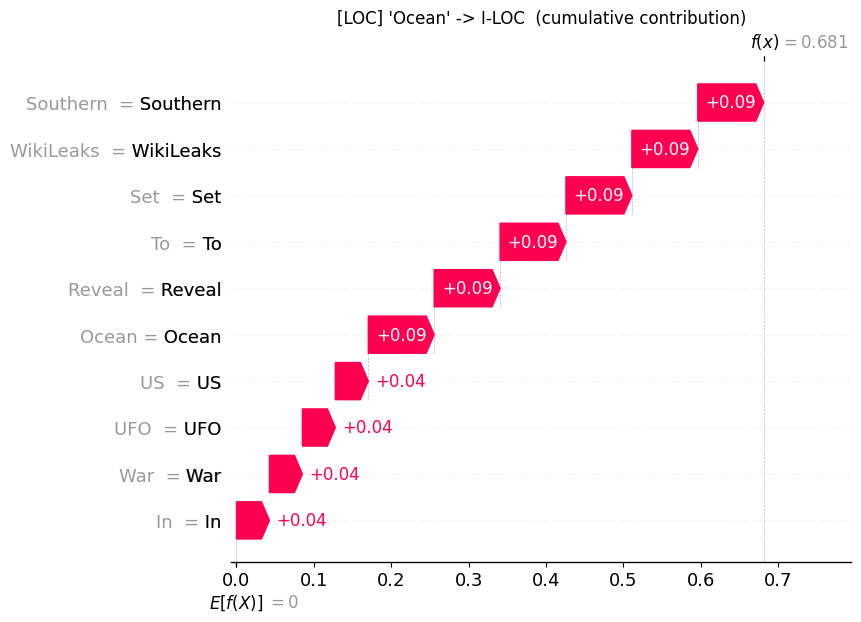


CATEGORY: ORG  (1 occurrence)

Word: 'WikiLeaks'  ->  B-ORG  (confidence=0.889)


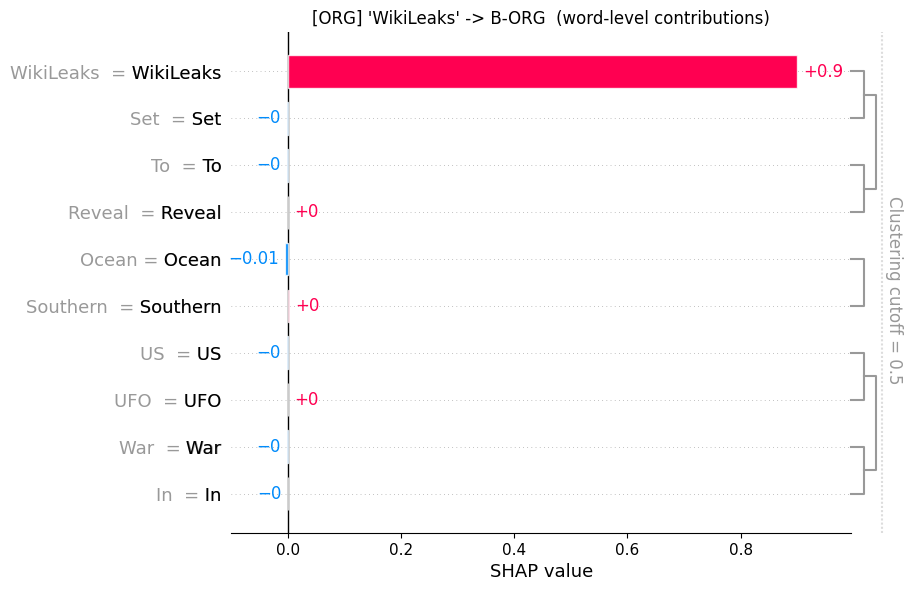

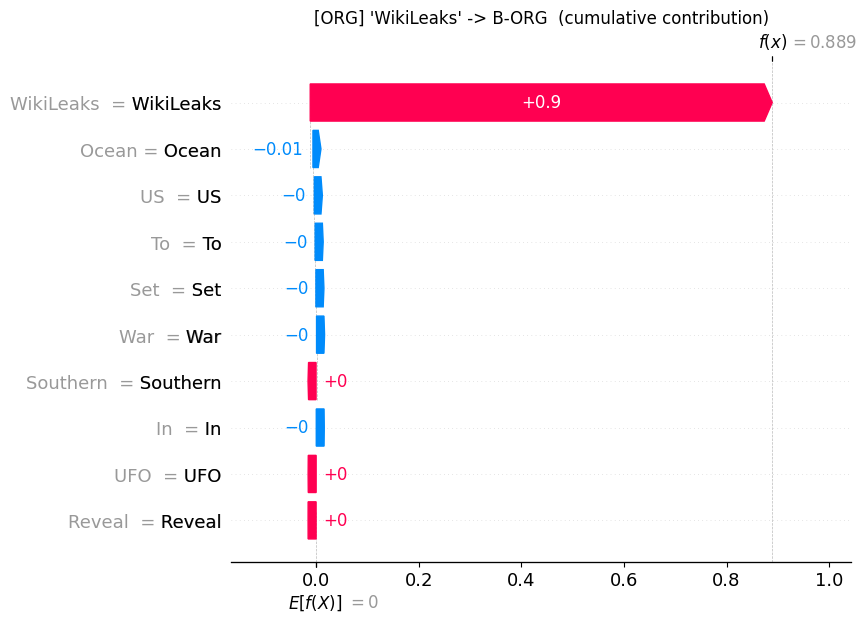

In [9]:
explain_by_category(TWEET)

### 7a. Optional: highlighted-text view

`shap.plots.text()` renders the whole tweet inline with each word
shaded by its contribution - useful for a quick visual scan, though
the bar/waterfall plots above are easier to read precise values from.
This renders as interactive HTML directly in the notebook output.

In [10]:
def explain_entity_as_text(text, word_idx):
    """Renders shap.plots.text() for one specific predicted entity
    (by its word index in `text.split()`)."""
    preds = predict_entities(text)
    word, label, conf = preds[word_idx]
    target_label_id = label2id[label]

    masker = shap.maskers.Text(tokenizer=r"\W+")
    predict_fn = make_word_label_predict_fn(word_idx, target_label_id)
    explainer = shap.Explainer(predict_fn, masker)
    shap_values = explainer([text])

    print(f"Word: '{word}' -> {label} (confidence={conf:.3f})")
    shap.plots.text(shap_values)


# example: explain the first PER entity this way (change CATEGORY or
# set it to None to just take the first predicted entity of any type)
CATEGORY = "PER"

preds = predict_entities(TWEET)
entity_positions = []
for i, (w, label, c) in enumerate(preds):
    if label == "O":
        continue
    bare_type = label.split("-", 1)[1] if "-" in label else label
    if CATEGORY is None or bare_type == CATEGORY.upper():
        entity_positions.append(i)

if entity_positions:
    explain_entity_as_text(TWEET, entity_positions[0])
else:
    print(f"No predicted entities matched category {CATEGORY!r} in this tweet.")

No predicted entities matched category 'PER' in this tweet.


## 8. LIME analysis

LIME (Local Interpretable Model-agnostic Explanations) is a different
explanation method from SHAP, worth comparing side by side:

- **SHAP** computes attributions based on Shapley values from game
  theory - exact (within sampling/approximation error), with solid
  theoretical guarantees about how credit is split between features.
- **LIME** takes a more direct approach: it generates many perturbed
  versions of the input (randomly removing words), gets the model's
  prediction for each, then fits a **simple linear model** to approximate
  how the real model behaves *in the local neighborhood of this one
  input*. The linear model's coefficients become the word importances.

Same underlying idea (perturb the input, see what changes), different
mechanics - and different practical tradeoffs: LIME's local linear fit
has its own approximation error, separate from the perturbation
sampling SHAP also relies on, so the two methods can disagree somewhat
even when both are working correctly.

Like the SHAP setup earlier, LIME needs a fixed-shape prediction
function - here framed as a binary problem: P(not the predicted label)
vs. P(the predicted label), at one fixed word position.

In [16]:
from lime.lime_text import LimeTextExplainer


def make_lime_predict_fn(target_word_index, target_label_id):
    """LIME needs classifier_fn(list_of_texts) -> 2D array of shape
    (n_texts, 2): [P(not target label), P(target label)] per text."""
    def predict(texts):
        results = []
        for text in texts:
            words = text.split()
            if target_word_index >= len(words) or len(words) == 0:
                results.append([1.0, 0.0])
                continue
            enc = tokenizer(words, is_split_into_words=True, truncation=True,
                             max_length=64, return_tensors="pt")
            with torch.no_grad():
                logits = model(**enc).logits[0]
            probs = torch.softmax(logits, dim=-1)
            word_ids = enc.word_ids()
            first_subword_pos = next(
                (pos for pos, wid in enumerate(word_ids) if wid == target_word_index),
                None,
            )
            if first_subword_pos is None:
                results.append([1.0, 0.0])
                continue
            p_target = probs[first_subword_pos, target_label_id].item()
            results.append([1.0 - p_target, p_target])
        return np.array(results)
    return predict

### 8a. Explain predicted categories with LIME

Mirrors `explain_by_category` from the SHAP section: groups by category,
each entity occurrence gets its own LIME explanation. `num_samples`
controls how many perturbed versions of the sentence LIME generates per
explanation - more samples gives a more stable result but takes longer.
1000 is a reasonable starting point; the library's own default is 5000,
which is noticeably slower on CPU for not much extra stability on short
tweet-length inputs.

**Color convention warning:** LIME's bar plot uses **red = pushes away
from the predicted label, green = pushes toward it** - the *opposite*
of SHAP's bar/waterfall plots used earlier (red = toward, blue = away).
Keep this in mind when comparing the two side by side in section 8b -
the colors don't mean the same thing across methods.

In [20]:
import matplotlib.pyplot as plt


def explain_by_category_lime(text, categories=None, num_samples=1000, num_features=10, show_plots=True):
    """Same category-grouping behavior as explain_by_category, but using
    LIME instead of SHAP. With show_plots=True (default), renders LIME's
    own bar chart per prediction; set False for the text-only printout."""
    if categories is not None:
        categories = {c.upper() for c in categories}

    preds = predict_entities(text)

    positions_by_category = {}
    for i, (w, label, c) in enumerate(preds):
        if label == "O":
            continue
        bare_type = label.split("-", 1)[1] if "-" in label else label
        if categories is not None and bare_type not in categories:
            continue
        positions_by_category.setdefault(bare_type, []).append(i)

    if not positions_by_category:
        if categories is None:
            print("No entities predicted in this tweet - nothing to explain.")
        else:
            print(f"No predicted entities matched categories {sorted(categories)} in this tweet.")
        return

    explainer = LimeTextExplainer(class_names=["not_label", "target_label"])

    for category in sorted(positions_by_category):
        word_indices = positions_by_category[category]
        print(f"\n{'=' * 60}")
        print(f"CATEGORY: {category}  ({len(word_indices)} occurrence{'s' if len(word_indices) != 1 else ''})")
        print(f"{'=' * 60}")

        for word_idx in word_indices:
            word, label, conf = preds[word_idx]
            target_label_id = label2id[label]

            predict_fn = make_lime_predict_fn(word_idx, target_label_id)
            explanation = explainer.explain_instance(
                text, predict_fn, labels=[1],
                num_features=num_features, num_samples=num_samples,
            )

            print(f"\nWord: '{word}'  ->  {label}  (confidence={conf:.3f})")
            print(f"LIME local model fit (R^2): {explanation.score:.3f}")

            if show_plots:
                fig = explanation.as_pyplot_figure(label=1)
                fig.suptitle(f"[{category}] '{word}' -> {label}  (LIME word importances)")
                plt.show()
            else:
                print("Word importances (ranked by magnitude):")
                for w, weight in explanation.as_list(label=1):
                    bar = "+" * min(int(abs(weight) * 200), 40) if weight > 0 else "-" * min(int(abs(weight) * 200), 40)
                    print(f"  {w:15s} {weight:+.4f}  {bar}")

Examples:
- `explain_by_category_lime(TWEET)` - explain every predicted category, with plots
- `explain_by_category_lime(TWEET, categories=["PER"])` - only PER
- `explain_by_category_lime(TWEET, num_samples=2000)` - more samples, slower but more stable
- `explain_by_category_lime(TWEET, show_plots=False)` - text-only, no plots


CATEGORY: MISC  (1 occurrence)

Word: 'Knight'  ->  I-MISC  (confidence=0.542)
LIME local model fit (R^2): 0.402


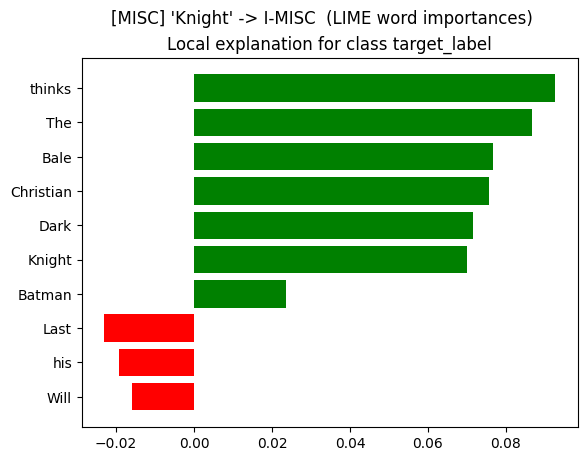


CATEGORY: PER  (2 occurrences)

Word: 'Christian'  ->  B-PER  (confidence=0.995)
LIME local model fit (R^2): 0.821


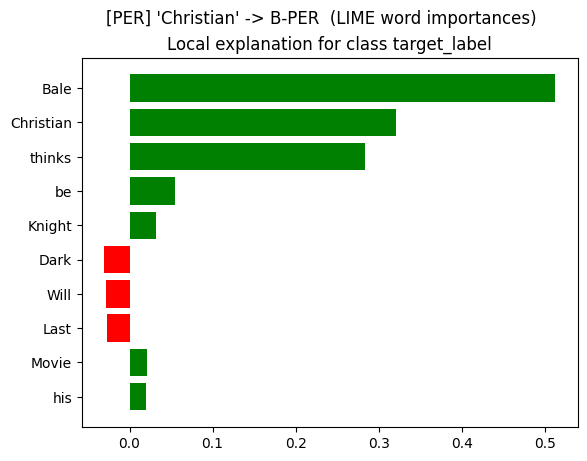


Word: 'Bale'  ->  I-PER  (confidence=0.990)
LIME local model fit (R^2): 0.806


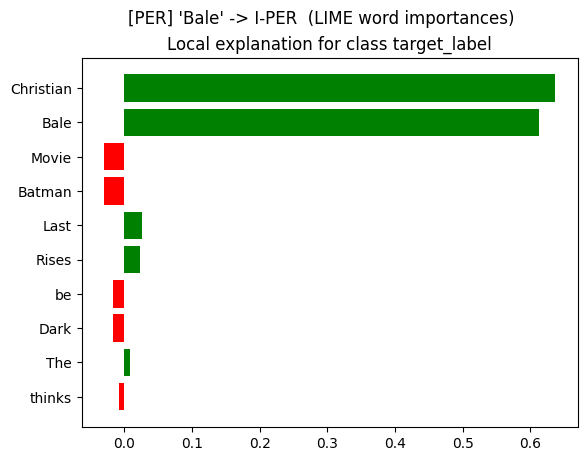

In [25]:
explain_by_category_lime(TWEET)

### 8b. Comparing SHAP and LIME on the same prediction

Worth doing explicitly for your report: run both methods on the same
(word, label) prediction and compare which words each ranks as most
important. Large disagreements are worth investigating - they can
reveal whether one method is picking up on a real, robust pattern, or
whether the explanation is sensitive to the specific approximation
method used (a known limitation worth being upfront about for any XAI
method, not unique to either SHAP or LIME).

In [14]:
def compare_shap_lime(text, word_idx, num_samples=1000):
    preds = predict_entities(text)
    word, label, conf = preds[word_idx]
    target_label_id = label2id[label]
    print(f"Comparing explanations for: '{word}' -> {label} (confidence={conf:.3f})\n")

    # SHAP
    masker = shap.maskers.Text(tokenizer=r"\W+")
    shap_predict_fn = make_word_label_predict_fn(word_idx, target_label_id)
    shap_explainer = shap.Explainer(shap_predict_fn, masker)
    shap_values = shap_explainer([text])

    print("SHAP (ranked by signed value):")
    pairs = list(zip(shap_values.data[0], shap_values.values[0]))
    pairs.sort(key=lambda p: -abs(p[1]))
    for tok, val in pairs[:10]:
        print(f"  {tok.strip():15s} {val:+.4f}")

    # LIME
    print("\nLIME (ranked by magnitude):")
    lime_predict_fn = make_lime_predict_fn(word_idx, target_label_id)
    lime_explainer = LimeTextExplainer(class_names=["not_label", "target_label"])
    explanation = lime_explainer.explain_instance(
        text, lime_predict_fn, labels=[1], num_features=10, num_samples=num_samples,
    )
    for w, weight in explanation.as_list(label=1):
        print(f"  {w:15s} {weight:+.4f}")


# example: compare both methods on the first predicted entity
preds = predict_entities(TWEET)
entity_positions = [i for i, (w, label, c) in enumerate(preds) if label != "O"]
if entity_positions:
    compare_shap_lime(TWEET, entity_positions[0])

Comparing explanations for: 'WikiLeaks' -> B-ORG (confidence=0.889)

SHAP (ranked by signed value):
  WikiLeaks       +0.9004
  Ocean           -0.0053
  US              -0.0027
  To              -0.0016
  Set             -0.0015
  War             -0.0012
  Southern        +0.0010
  In              -0.0004
  UFO             +0.0003
  Reveal          +0.0001

LIME (ranked by magnitude):
  WikiLeaks       +0.8667
  To              -0.0166
  Reveal          -0.0149
  Set             -0.0116
  UFO             +0.0056
  US              +0.0054
  Ocean           -0.0052
  War             +0.0027
  In              +0.0018
  Southern        +0.0000
